# DeepCSAT
**Updated:** 2025-10-06 13:06 UTC

### Overview
- **Goal:** Predict Customer Satisfaction (CSAT) from e-commerce support data.
- **Dataset:** eCommerce_Customer_support_data.csv — includes textual customer interactions and satisfaction scores.
- **Model:** BiLSTM (Bidirectional LSTM) text classifier using TensorFlow / Keras.
- **Metrics:** Accuracy, F1-score, Confusion Matrix.
- **Pipeline:** Data loading → Cleaning → Vectorization → Model training → Evaluation → Inference.

### Key Features
- Deterministic seed setup for reproducibility.
- GPU detection and memory growth configuration.
- Data cleaning and preprocessing for text columns.
- Model checkpointing, early stopping, and training logs.
- Visual evaluation (loss curve, confusion matrix).
- Exported model, label encoder, and vectorizers for reuse.

### Next Steps
- Perform hyperparameter tuning for better generalization.
- Integrate explainability (SHAP / LIME).
- Deploy using Flask / FastAPI / TF Serving.


# DeepCSAT — Notebook
**Purpose:** train a model to predict CSAT (Customer Satisfaction Score) from customer support data.  
**Author:** Auto-updated by assistant on 2025-10-06 12:23 UTC
**Dataset:** `eCommerce_Customer_support_data.csv` (expected columns: customer text columns, `CSAT Score`)  
**How to run:**  
1. Install dependencies (run the requirements cell).  
2. Run cells top-to-bottom.  
3. Output artifacts will be stored in `./outputs/` (model, vectorizer, reports).  

**Notebook structure**
- Environment / requirements
- Reproducibility (seeds, device)
- Data loading & preview
- Preprocessing
- Model build & training
- Evaluation & explainability
- Inference / smoke-tests
- Save artifacts & next steps


In [ ]:
# Requirements (uncomment installation lines if needed)
!pip install pandas scikit-learn tensorflow python-pptx matplotlib seaborn joblib shap
# Optionally create requirements.txt after successful installs:
!pip freeze > requirements.txt
print('Requirements cell: review and install packages if needed.')

Requirements cell: review and install packages if needed.


In [ ]:
# Determinism & device check
import os, random
import numpy as np
import tensorflow as tf

PY_SEED = 42
os.environ['PYTHONHASHSEED'] = str(PY_SEED)
random.seed(PY_SEED)
np.random.seed(PY_SEED)
tf.random.set_seed(PY_SEED)

gpus = tf.config.list_physical_devices('GPU')
print('GPUs found:', gpus)
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print('GPU memory growth set.')
    except Exception as e:
        print('GPU config error:', e)

GPUs found: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
GPU memory growth set.


In [ ]:
# Path configuration (avoid hardcoded absolute paths)
from pathlib import Path
DATA_PATH = Path('/content/eCommerce_Customer_support_data.csv')  # update if needed
OUTPUT_DIR = Path('outputs')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print('DATA_PATH ->', DATA_PATH.resolve())
print('OUTPUT_DIR ->', OUTPUT_DIR.resolve())

DATA_PATH -> /content/eCommerce_Customer_support_data.csv
OUTPUT_DIR -> /content/outputs


In [ ]:
# Data loading & quick preview
import pandas as pd
df = pd.read_csv(DATA_PATH)
print('Data shape:', df.shape)
display(df.head(5))
display(df.sample(5, random_state=PY_SEED))

# detect likely target column
possible_targets = [c for c in df.columns if c.lower() in ('csat score','csat','satisfaction','rating','score')]
target_col = possible_targets[0] if possible_targets else df.columns[-1]
print('Using target column:', target_col)
print(df[target_col].value_counts(dropna=False).sort_index())

Data shape: (85907, 20)


,Unique id,channel_name,category,Sub-category,Customer Remarks,Order_id,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,Item_price,connected_handling_time,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score
0,7e9ae164-6a8b-4521-a2d4-58f7c9fff13f,Outcall,Product Queries,Life Insurance,NaN,c27c9bb4-fa36-4140-9f1f-21009254ffdb,NaN,01/08/2023 11:13,01/08/2023 11:47,01-Aug-23,NaN,NaN,NaN,NaN,Richard Buchanan,Mason Gupta,Jennifer Nguyen,On Job Training,Morning,5
1,b07ec1b0-f376-43b6-86df-ec03da3b2e16,Outcall,Product Queries,Product Specific Information,NaN,d406b0c7-ce17-4654-b9de-f08d421254bd,NaN,01/08/2023 12:52,01/08/2023 12:54,01-Aug-23,NaN,NaN,NaN,NaN,Vicki Collins,Dylan Kim,Michael Lee,>90,Morning,5
2,200814dd-27c7-4149-ba2b-bd3af3092880,Inbound,Order Related,Installation/demo,NaN,c273368d-b961-44cb-beaf-62d6fd6c00d5,NaN,01/08/2023 20:16,01/08/2023 20:38,01-Aug-23,NaN,NaN,NaN,NaN,Duane Norman,Jackson Park,William Kim,On Job Training,Evening,5
3,eb0d3e53-c1ca-42d3-8486-e42c8d622135,Inbound,Returns,Reverse Pickup Enquiry,NaN,5aed0059-55a4-4ec6-bb54-97942092020a,NaN,01/08/2023 20:56,01/08/2023 21:16,01-Aug-23,NaN,NaN,NaN,NaN,Patrick Flores,Olivia Wang,John Smith,>90,Evening,5
4,ba903143-1e54-406c-b969-46c52f92e5df,Inbound,Cancellation,Not Needed,NaN,e8bed5a9-6933-4aff-9dc6-ccefd7dcde59,NaN,01/08/2023 10:30,01/08/2023 10:32,01-Aug-23,NaN,NaN,NaN,NaN,Christopher Sanchez,Austin Johnson,Michael Lee,0-30,Morning,5


,Unique id,channel_name,category,Sub-category,Customer Remarks,Order_id,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,Item_price,connected_handling_time,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score
67871,fc42f862-7521-472c-b569-8bce866ebe8c,Inbound,Returns,Fraudulent User,NaN,111a13cc-161e-4605-bf68-4e85d2e780c8,NaN,26/08/2023 18:39,26/08/2023 18:48,26-Aug-23,NaN,NaN,NaN,NaN,Brittney Key,Mia Yamamoto,Jennifer Nguyen,On Job Training,Morning,5
40187,a7bb8900-a120-430f-b573-55ed6c16faab,Inbound,Returns,Reverse Pickup Enquiry,Retain employees like this guy. Short and simp...,cbe87ffe-fb02-4f58-97a0-b4f9868d8d6a,09/08/2023 11:15,14/08/2023 00:32,14/08/2023 00:37,14-Aug-23,MUMBAI,Books & General merchandise,156.0,NaN,Jacqueline Meadows,Ethan Nakamura,Emily Chen,0-30,Evening,5
60075,b697f809-0d10-4839-9ccd-152ab6a179f4,Outcall,Returns,Reverse Pickup Enquiry,NaN,3fe3922c-8eac-4274-b1d4-2e10ce94570c,NaN,22/08/2023 20:48,23/08/2023 15:54,23-Aug-23,NaN,NaN,NaN,NaN,Craig Henderson,Brayden Wong,John Smith,>90,Evening,5
69560,8952de8c-48fc-4c9b-b65e-bda8c531e2d5,Inbound,Payments related,Online Payment Issues,Trusted 100/,4bf4fd66-49dc-4a90-8b58-3cd64c9a3aaf,NaN,26/08/2023 23:47,26/08/2023 23:55,26-Aug-23,NaN,NaN,NaN,NaN,Samantha Swanson,Ava Wong,William Kim,On Job Training,Evening,5
2605,fc1c67bc-cb0d-444e-a6da-e5fa6392083b,Inbound,Returns,Reverse Pickup Enquiry,NaN,4e97c673-9132-48cd-a5f4-07b1e292377f,27/07/2023 21:36,01/08/2023 18:37,01/08/2023 18:38,01-Aug-23,PATNA,LifeStyle,294.0,NaN,Stephen Morris,Wyatt Kim,Michael Lee,>90,Evening,5


Using target column: CSAT Score
CSAT Score
1    11230
2     1283
3     2558
4    11219
5    59617
Name: count, dtype: int64


In [ ]:
# Preprocessing: combine text columns and clean
import re
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import joblib

text_cols = df.select_dtypes(include=['object']).columns.tolist()
text_cols = [c for c in text_cols if c != target_col]
print('Text columns detected (sample):', text_cols[:8])

df['text'] = df[text_cols].astype(str).agg(' | '.join, axis=1)

def clean_text(s):
    s = str(s).replace('\n',' ').replace('\r',' ')
    s = re.sub(r'http\S+', '', s)
    s = re.sub(r'[^0-9A-Za-z,.!?%:;()| ]+', ' ', s)
    s = re.sub(r'\s+', ' ', s).strip()
    return s.lower()

df['text_clean'] = df['text'].apply(clean_text)

le = LabelEncoder()
y = le.fit_transform(df[target_col].astype(str))
joblib.dump(le, OUTPUT_DIR / 'label_encoder.joblib')
print('Saved label encoder with classes:', le.classes_)

# Train / val / test splits (stratified for classification)
X = df['text_clean']
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.20, random_state=PY_SEED, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=PY_SEED, stratify=y_temp)
print('Splits sizes (train/val/test):', len(X_train), len(X_val), len(X_test))

Text columns detected (sample): ['Unique id', 'channel_name', 'category', 'Sub-category', 'Customer Remarks', 'Order_id', 'order_date_time', 'Issue_reported at']
Saved label encoder with classes: ['1' '2' '3' '4' '5']
Splits sizes (train/val/test): 68725 8591 8591


In [ ]:
# Save preprocessing pipeline: TF-IDF and Keras TextVectorization examples
from sklearn.feature_extraction.text import TfidfVectorizer
from tensorflow.keras.layers import TextVectorization

# TF-IDF (lightweight)
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2), stop_words='english')
tfidf.fit(X_train)
joblib.dump(tfidf, OUTPUT_DIR / 'tfidf_vectorizer.joblib')
print('Saved TF-IDF vectorizer.')

# Keras TextVectorization (for TF model)
max_tokens = 15000; seq_len = 200
vectorize = TextVectorization(max_tokens=max_tokens, output_sequence_length=seq_len, output_mode='int')
vectorize.adapt(X_train.to_numpy())
vocab = vectorize.get_vocabulary()
with open(OUTPUT_DIR / 'vocab.txt', 'w', encoding='utf-8') as f:
    f.write('\n'.join(vocab))
print('Saved TextVectorization vocab (length=%d).' % len(vocab))

Saved TF-IDF vectorizer.
Saved TextVectorization vocab (length=15000).


In [ ]:
# Build BiLSTM model (Keras)
from tensorflow import keras
from tensorflow.keras import layers

num_classes = len(le.classes_)
def build_bilstm_model(max_tokens=15000, seq_len=200, embed_dim=128, num_classes=None):
    inputs = keras.Input(shape=(seq_len,), dtype='int32')
    x = layers.Embedding(input_dim=max_tokens, output_dim=embed_dim, mask_zero=True)(inputs)
    x = layers.Bidirectional(layers.LSTM(128, return_sequences=True))(x)
    x = layers.GlobalMaxPool1D()(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    if num_classes == 2:
        outputs = layers.Dense(1, activation='sigmoid')(x)
        loss = 'binary_crossentropy'; metrics = ['accuracy']
    else:
        outputs = layers.Dense(num_classes, activation='softmax')(x)
        loss = 'sparse_categorical_crossentropy'; metrics = ['accuracy']
    model = keras.Model(inputs, outputs)
    model.compile(optimizer='adam', loss=loss, metrics=metrics)
    return model

model = build_bilstm_model(max_tokens=max_tokens, seq_len=seq_len, embed_dim=128, num_classes=num_classes)
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:965: UserWarning: Layer 'global_max_pooling1d' (of type GlobalMaxPooling1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 200)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 200, 128)  │  1,920,000 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 200)       │          0 │ input_layer[0][0] │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 200, 256)  │    263,168 │ embedding[0][0],  │
│ (Bidirectional)     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 256)       │          0 │ bidirectional[0]… │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │     16,448 │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 5)         │        325 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,199,941 (8.39 MB)

 Trainable params: 2,199,941 (8.39 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Training with callbacks (ModelCheckpoint, CSVLogger, EarlyStopping)
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, CSVLogger
import tensorflow as tf

checkpoint_path = OUTPUT_DIR / 'best_model.h5'
csv_log_path = OUTPUT_DIR / 'training_log.csv'

callbacks = [
    ModelCheckpoint(str(checkpoint_path), monitor='val_loss', save_best_only=True, verbose=1),
    EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True),
    CSVLogger(str(csv_log_path))
]

BATCH_SIZE = 64
def make_ds(text_series, labels, vectorize_layer, batch_size=64, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((text_series.values, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(text_series), seed=PY_SEED)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    ds = ds.map(lambda x,y: (vectorize_layer(x), y), num_parallel_calls=tf.data.AUTOTUNE)
    return ds

train_ds = make_ds(X_train, y_train, vectorize, batch_size=BATCH_SIZE, shuffle=True)
val_ds = make_ds(X_val, y_val, vectorize, batch_size=BATCH_SIZE, shuffle=False)

history = model.fit(train_ds, validation_data=val_ds, epochs=12, callbacks=callbacks)
model.save(OUTPUT_DIR / 'final_saved_model.keras')

Epoch 1/12
1074/1074 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7065 - loss: 0.9438
Epoch 1: val_loss improved from inf to 0.85856, saving model to outputs/best_model.h5


1074/1074 ━━━━━━━━━━━━━━━━━━━━ 25s 17ms/step - accuracy: 0.7065 - loss: 0.9437 - val_accuracy: 0.7239 - val_loss: 0.8586
Epoch 2/12
1071/1074 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7305 - loss: 0.8273
Epoch 2: val_loss did not improve from 0.85856
1074/1074 ━━━━━━━━━━━━━━━━━━━━ 17s 16ms/step - accuracy: 0.7305 - loss: 0.8273 - val_accuracy: 0.7211 - val_loss: 0.8765
Epoch 3/12
1073/1074 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7486 - loss: 0.7205
Epoch 3: val_loss did not improve from 0.85856
1074/1074 ━━━━━━━━━━━━━━━━━━━━ 19s 17ms/step - accuracy: 0.7486 - loss: 0.7205 - val_accuracy: 0.7119 - val_loss: 0.9304
Epoch 4/12
1072/1074 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.7762 - loss: 0.5928
Epoch 4: val_loss did not improve from 0.85856
1074/1074 ━━━━━━━━━━━━━━━━━━━━ 23s 20ms/step - accuracy: 0.7762 - loss: 0.5928 - val_accuracy: 0.7029 - val_loss: 1.0977
Epoch 5/12
1073/1074 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8161 - loss: 0.4739
Epoch 5: val_loss d

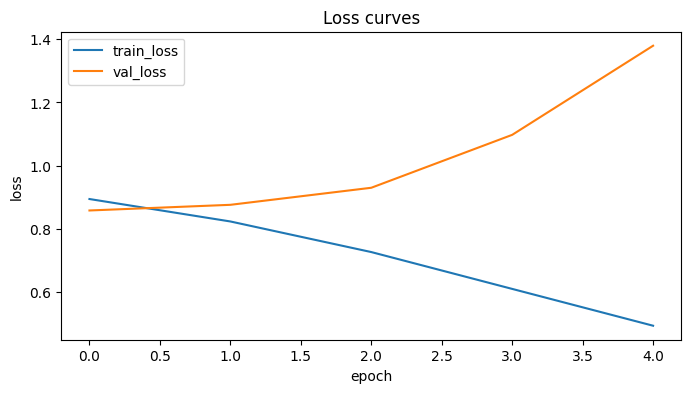

In [ ]:
# Save training history and plot loss curves
import pandas as pd
import matplotlib.pyplot as plt
hist_df = pd.DataFrame(history.history)
hist_df.to_csv(OUTPUT_DIR / 'history.csv', index=False)
plt.figure(figsize=(8,4))
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend(); plt.title('Loss curves'); plt.xlabel('epoch'); plt.ylabel('loss')
plt.savefig(OUTPUT_DIR / 'loss_plot.png')
plt.show()

135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
              precision    recall  f1-score   support

           1     0.6996    0.3402    0.4578      1123
           2     0.0000    0.0000    0.0000       128
           3     0.0000    0.0000    0.0000       256
           4     0.0000    0.0000    0.0000      1122
           5     0.7298    0.9847    0.8383      5962

    accuracy                         0.7279      8591
   macro avg     0.2859    0.2650    0.2592      8591
weighted avg     0.5979    0.7279    0.6416      8591



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


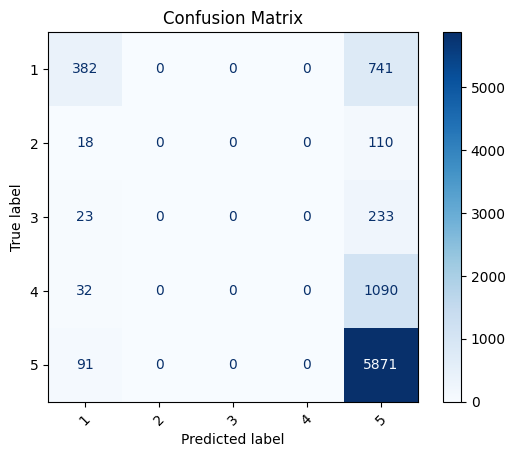

In [ ]:
# Evaluation: classification report and confusion matrix
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import numpy as np
test_ds = make_ds(X_test, y_test, vectorize, batch_size=BATCH_SIZE, shuffle=False)
y_pred_raw = model.predict(test_ds)
if num_classes == 2:
    y_pred = (y_pred_raw.squeeze() >= 0.5).astype(int)
else:
    y_pred = np.argmax(y_pred_raw, axis=1)

report = classification_report(y_test, y_pred, target_names=le.classes_, digits=4)
print(report)
with open(OUTPUT_DIR / 'classification_report.txt', 'w', encoding='utf-8') as f:
    f.write(report)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=le.classes_)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title('Confusion Matrix')
plt.savefig(OUTPUT_DIR / 'confusion_matrix.png')
plt.show()

In [ ]:
# Inference / smoke tests
def infer_texts(texts):
    cleaned = [clean_text(t) for t in texts]
    tokens = vectorize(tf.constant(cleaned))
    preds = model.predict(tokens)
    if num_classes == 2:
        labs = (preds.squeeze() >= 0.5).astype(int)
    else:
        labs = preds.argmax(axis=1)
    return [le.inverse_transform([lab])[0] for lab in labs]

examples = [
    "Agent resolved my issue quickly and politely.",
    "They charged me extra and refused refund — very disappointed."
]
print('Examples ->', infer_texts(examples))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step
Examples -> ['5', '1']


/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:965: UserWarning: Layer 'global_max_pooling1d' (of type GlobalMaxPooling1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


In [ ]:
# Minimal assertions / smoke tests
assert len(X_train) > 0 and len(X_test) > 0, 'Train/test splits empty!'
_sample = infer_texts(['test message'])
assert _sample is not None, 'Inference returned None'
print('Smoke tests passed.')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 238ms/step
Smoke tests passed.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:965: UserWarning: Layer 'global_max_pooling1d' (of type GlobalMaxPooling1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


In [ ]:
# ---------- Configure before running ----------
# Set S3 destination (if you want upload). If you don't want to upload, set S3_BUCKET=None
S3_BUCKET = None    # <-- change to your bucket or set to None
S3_KEY_PREFIX = "models"                  # will store as models/model.joblib or models/model.pt etc.
AWS_REGION = "ap-south-1"                 # adjust if needed
# If you already know the model variable name in this notebook, set it here (string).
# Otherwise leave as None to let the auto-detector try to find it.
MODEL_VAR_NAME = None                     # e.g. "model" or "clf" or "net"
# ------------------------------------------------

import inspect
import types
candidates = []

# helper type checks (we try-import optional libs)
sklearn_BaseEstimator = None
tf_keras_Model = None
torch_Module = None
xgb_Booster = None
lgb_Booster = None

try:
    from sklearn.base import BaseEstimator as sklearn_BaseEstimator
except Exception:
    sklearn_BaseEstimator = None

try:
    import tensorflow as tf
    tf_keras_Model = tf.keras.Model
except Exception:
    tf_keras_Model = None

try:
    import torch
    torch_Module = torch.nn.Module
except Exception:
    torch_Module = None

try:
    import xgboost as xgb
    xgb_Booster = xgb.Booster
except Exception:
    xgb_Booster = None

try:
    import lightgbm as lgb
    lgb_Booster = lgb.Booster
except Exception:
    lgb_Booster = None

# scan globals for objects that look like models
for name, obj in list(globals().items()):
    if name.startswith("_"):
        continue
    try:
        t = type(obj)
        # sklearn-like
        if sklearn_BaseEstimator is not None and isinstance(obj, sklearn_BaseEstimator):
            candidates.append((name, "sklearn", obj))
            continue
        # xgboost booster or sklearn wrapper
        if xgb_Booster is not None and isinstance(obj, xgb_Booster):
            candidates.append((name, "xgboost", obj))
            continue
        # lightgbm
        if lgb_Booster is not None and isinstance(obj, lgb_Booster):
            candidates.append((name, "lightgbm", obj))
            continue
        # tf keras
        if tf_keras_Model is not None and isinstance(obj, tf_keras_Model):
            candidates.append((name, "tensorflow", obj))
            continue
        # torch
        if torch_Module is not None and isinstance(obj, torch_Module):
            candidates.append((name, "pytorch", obj))
            continue
        # heuristics: common variable names or types
        if name.lower() in ("model","clf","classifier","regressor","net","model_tf","model_keras","trained_model"):
            candidates.append((name, "heuristic", obj))
    except Exception:
        pass

# If user set MODEL_VAR_NAME, prioritize it
if MODEL_VAR_NAME:
    if MODEL_VAR_NAME in globals():
        obj = globals()[MODEL_VAR_NAME]
        print(f"Using explicitly provided variable: {MODEL_VAR_NAME} (type: {type(obj)})")
        candidates = [(MODEL_VAR_NAME, "explicit", obj)]
    else:
        print(f"ERROR: MODEL_VAR_NAME='{MODEL_VAR_NAME}' was set but not found in globals().")

if not candidates:
    print("No model-like objects auto-detected in globals().")
    print("You should set MODEL_VAR_NAME to the variable name of the trained model (e.g., 'model' or 'clf').")
else:
    print("Detected candidate model variables:")
    for i, (n, kind, obj) in enumerate(candidates):
        print(f"  [{i}] name='{n}', kind='{kind}', type={type(obj)}")
    # pick the first candidate by default
    chosen_name, chosen_kind, chosen_obj = candidates[0]
    print(f"\nDefaulting to first candidate: name='{chosen_name}', kind='{chosen_kind}'")

# ------------------------------------------------
import os
import joblib
import json

# ensure we have a 'chosen_obj' from previous cell
try:
    chosen_name
    chosen_obj
    chosen_kind
except NameError:
    raise RuntimeError("No model chosen. Run cell 2 and set MODEL_VAR_NAME if necessary.")

artifact_path = None

if chosen_kind in ("sklearn","heuristic","explicit"):
    artifact_path = "model.joblib"
    joblib.dump(chosen_obj, artifact_path)
    print(f"Saved scikit-learn model to {artifact_path}")

elif chosen_kind == "xgboost":
    # XGBoost native booster
    artifact_path = "model.xgb"
    try:
        chosen_obj.save_model(artifact_path)
        print(f"Saved XGBoost model to {artifact_path}")
    except Exception as e:
        # try joblib fallback
        joblib.dump(chosen_obj, "model.joblib")
        artifact_path = "model.joblib"
        print(f"XGBoost save_model failed, fallback saved via joblib to {artifact_path}: {e}")

elif chosen_kind == "lightgbm":
    artifact_path = "model.lgb"
    try:
        chosen_obj.save_model(artifact_path)
        print(f"Saved LightGBM model to {artifact_path}")
    except Exception as e:
        joblib.dump(chosen_obj, "model.joblib")
        artifact_path = "model.joblib"
        print(f"LightGBM save_model failed, fallback saved via joblib to {artifact_path}: {e}")

elif chosen_kind == "tensorflow":
    # For TF Keras model, save as SavedModel dir (recommended) and also .h5 fallback
    artifact_path = "saved_model"
    try:
        chosen_obj.save(artifact_path, save_format="tf")
        print(f"Saved TensorFlow model as SavedModel directory: {artifact_path}/")
    except Exception as e:
        # fallback to h5
        artifact_path = "model.h5"
        chosen_obj.save(artifact_path)
        print(f"Saved TensorFlow model fallback to {artifact_path}: {e}")

elif chosen_kind == "pytorch":
    artifact_path = "model.pt"
    import torch
    try:
        # try save state_dict if model has state_dict
        if hasattr(chosen_obj, "state_dict"):
            torch.save(chosen_obj.state_dict(), artifact_path)
            print(f"Saved PyTorch model state_dict to {artifact_path}")
        else:
            # save entire model (may require class definition available on load)
            torch.save(chosen_obj, artifact_path)
            print(f"Saved PyTorch model object to {artifact_path}")
    except Exception as e:
        # fallback joblib
        joblib.dump(chosen_obj, "model.joblib")
        artifact_path = "model.joblib"
        print(f"PyTorch save failed, fallback via joblib to {artifact_path}: {e}")
else:
    # generic fallback
    artifact_path = "model.joblib"
    joblib.dump(chosen_obj, artifact_path)
    print(f"Generic fallback saved object via joblib to {artifact_path}")
# ------------------------------------------------

if S3_BUCKET:
    import boto3
    import botocore
    s3 = boto3.client("s3", region_name=AWS_REGION)
    # ensure bucket exists (create if not)
    try:
        s3.head_bucket(Bucket=S3_BUCKET)
    except botocore.exceptions.ClientError as e:
        # Try to create (will fail if you don't have permission)
        print(f"Bucket {S3_BUCKET} not found or inaccessible. Attempting to create it...")
        try:
            s3.create_bucket(Bucket=S3_BUCKET,
                             CreateBucketConfiguration={'LocationConstraint': AWS_REGION})
            print(f"Created bucket: {S3_BUCKET}")
        except Exception as e2:
            print(f"Failed to create bucket: {e2}")
            raise

    # Upload
    base_name = os.path.basename(artifact_path.rstrip("/"))
    s3_key = f"{S3_KEY_PREFIX.rstrip('/')}/{base_name}"
    print(f"Uploading {artifact_path} -> s3://{S3_BUCKET}/{s3_key} ...")
    try:
        if os.path.isdir(artifact_path):
            # if this is a TF SavedModel directory, upload recursively
            import pathlib
            for root, dirs, files in os.walk(artifact_path):
                for f in files:
                    full = os.path.join(root, f)
                    rel = os.path.relpath(full, artifact_path)
                    key = f"{S3_KEY_PREFIX.rstrip('/')}/{base_name}/{rel}"
                    s3.upload_file(full, S3_BUCKET, key)
            print("Uploaded SavedModel directory to S3.")
        else:
            s3.upload_file(artifact_path, S3_BUCKET, s3_key)
            print("Upload complete.")
    except Exception as e:
        print(f"Upload failed: {e}")

    print(f"Artifact S3 location: s3://{S3_BUCKET}/{s3_key}")
else:
    print("S3_BUCKET is None — skipping upload step. You can copy the artifact manually.")
# ------------------------------------------------


# Quick smoke test: try loading artifact we saved
print("Artifact saved at:", artifact_path)
try:
    if artifact_path.endswith(".joblib") or artifact_path.endswith(".pkl"):
        import joblib
        m = joblib.load(artifact_path)
        print("Loaded artifact; example type:", type(m))
    elif artifact_path.endswith(".pt"):
        import torch
        try:
            # try load state dict vs model object
            sd = torch.load(artifact_path)
            print("Loaded PyTorch object/state_dict type:", type(sd))
        except Exception as e:
            print("PyTorch load failed:", e)
    elif artifact_path.endswith(".h5") or artifact_path == "saved_model":
        import tensorflow as tf
        try:
            m = tf.keras.models.load_model(artifact_path)
            print("Loaded TF/Keras model; summary:")
            try:
                m.summary()
            except Exception:
                pass
        except Exception as e:
            print("TF load failed:", e)
    else:
        print("Artifact format unknown; inspect manually.")
except Exception as e:
    print("Error loading artifact:", e)

Detected candidate model variables:
  [0] name='le', kind='sklearn', type=<class 'sklearn.preprocessing._label.LabelEncoder'>
  [1] name='tfidf', kind='sklearn', type=<class 'sklearn.feature_extraction.text.TfidfVectorizer'>
  [2] name='model', kind='tensorflow', type=<class 'keras.src.models.functional.Functional'>

Defaulting to first candidate: name='le', kind='sklearn'
Saved scikit-learn model to model.joblib
S3_BUCKET is None — skipping upload step. You can copy the artifact manually.
Artifact saved at: model.joblib
Loaded artifact; example type: <class 'sklearn.preprocessing._label.LabelEncoder'>
